# How well do our models perform? 

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys

from sklearn.linear_model import ElasticNetCV
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error

data_directory = "../Data/unh_hackathon_prompt_2_data.json"
sys.path.append("../threat-response-planning/")

In [4]:
def load_predictive_warfighting_data(file_path: str = "unh_hackathon_prompt_2_data.json") -> pd.DataFrame:
    """Load data from a CSV file into a pandas DataFrame."""
    return pd.read_json(file_path)

In [ ]:
def load_and_clean_data(file_path: str) -> pd.DataFrame:
    """Load and clean the data."""
    df = pd.read_json(file_path)
    
    # Convert the string "NULL" to pd.NA
    df = df.replace("NULL", pd.NA)
    df = df.replace("N/A", pd.NA)

    # Convert numeric string columns
    for numeric_string_column in [
        "Enemy.Capability.Index",
        "EW_Capability",
        "Intel Confidence",
    ]:
        df[numeric_string_column] = pd.to_numeric(df[numeric_string_column])

    # Convert boolean string column
    df["response_success"] = df["response_success"].map({"Yes": 1, "No": 0, "1": 1, "0": 0})

    # Standardize threat type names
    # replace "msl" with "missile" and standardize case and whitespace
    
    df["Threat Type"] = df["Threat Type"].str.replace("msl", "missile", case=False, regex=True)
    df["Threat Type"] = df["Threat Type"].str.strip()  # Remove leading/trailing whitespace
    df["Threat Type"] = df["Threat Type"].str.lower()  # Convert to lowercase for consistency
    return df

In [6]:
df = load_and_clean_data(data_directory)
df['Threat Type'].unique()

<StringArray>
['missile', 'air', 'cyber', 'hybrid', 'naval']
Length: 5, dtype: str

## ElasticNetCV with PCA for Financial Loss 

In [7]:
threat_name = "naval"
target_col = "Financial_Loss_MUSD" # or "actual_days_to_stabilization"
df = load_and_clean_data(data_directory)
val_fraction = 0.2
random_state = 42
max_components = 26

# prepare data 
df = df.dropna() # drop rows with missing values for regression
input_columns = df.select_dtypes(include=[np.number]).columns.tolist()
# input_columns.remove('response_success')
input_columns.remove('Financial_Loss_MUSD')
input_columns.remove('actual_days_to_stabilization')

X = df[input_columns] # pd df of input variables 
if target_col == 'Financial_Loss_MUSD':
    y =  df['Financial_Loss_MUSD']
elif target_col == 'actual_days_to_stabilization':
    y = df['actual_days_to_stabilization']
else:
    raise ValueError(f"Invalid target_col: {target_col}. Must be 'Financial_Loss_MUSD' or 'actual_days_to_stabilization'.")
    
# train test (val) split 
val_size = int(len(X) * val_fraction)
indices = np.arange(len(X))
np.random.seed(random_state)
np.random.shuffle(indices)
    
val_indices = indices[:val_size]
train_indices = indices[val_size:]

X_train, X_val = X.iloc[train_indices], X.iloc[val_indices]
y_train, y_val = y.iloc[train_indices], y.iloc[val_indices]

# standardize 
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
    
# fit PCA with all components to get all eigenvalues
max_possible_components = min(max_components, X_train_scaled.shape[1], X_train_scaled.shape[0])
pca_full = PCA(n_components=max_possible_components)
pca_full.fit(X_train_scaled)

# test different numbers of components to find the best
best_mse = float('inf')
best_n_components = 1
best_model = None
best_pca = None

print(f"Testing {max_possible_components} different PCA configurations...")

for n_comp in range(1, max_possible_components + 1):
    # apply PCA with n_comp components
    pca = PCA(n_components=n_comp)
    X_train_pca = pca.fit_transform(X_train_scaled)
    X_val_pca = pca.transform(X_val_scaled)
    
    # train linear regression
    regr = ElasticNetCV(l1_ratio = [.1, .5, .7, .9, .95, .99, 1], cv=5, random_state=0)
    regr.fit(X_train_pca, y_train)
    
    # Evaluate on validation set
    val_mse = mean_squared_error(y_val, regr.predict(X_val_pca))
    
    if val_mse < best_mse:
        best_mse = val_mse
        best_n_components = n_comp
        best_model = regr
        best_pca = pca
        
# Report best configuration
print(f"\nBest Configuration:")
print(f"  Number of components: {best_n_components}")
print(f"  Validation MSE: {best_mse:.4f}")
cumulative_variance = np.sum(best_pca.explained_variance_ratio_) * 100
print(f"  Cumulative variance explained: {cumulative_variance:.2f}%")

Testing 25 different PCA configurations...

Best Configuration:
  Number of components: 25
  Validation MSE: 76.4412
  Cumulative variance explained: 100.00%


In [ ]:
def calculate_metrics(true_values, predictions, print_results=True):

    mae = mean_absolute_error(true_values, predictions)
    r2 = r2_score(true_values, predictions)
    rmse = np.sqrt(mean_squared_error(true_values, predictions))
    mape = np.mean(np.abs((true_values - predictions) / true_values)) * 100

    if print_results:
        print(f"Mean Absolute Error (MAE): {mae:.6f}")
        print(f"Root Mean Squared Error (RMSE): {rmse:.6f}")
        print(f"R² Score: {r2:.6f}")
        print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}%")  
    return mae, r2, rmse, mape

In [9]:
# get test metrics 
true_values = y_val
predictions = best_model.predict(best_pca.transform(X_val_scaled))
calculate_metrics(true_values, predictions)

Mean Absolute Error (MAE): 7.569945
Root Mean Squared Error (RMSE): 8.743065
R² Score: 0.989790
Mean Absolute Percentage Error (MAPE): 2.61%


(7.5699446783750135,
 0.9897895100995023,
 np.float64(8.743064547578316),
 np.float64(2.6143380837721777))

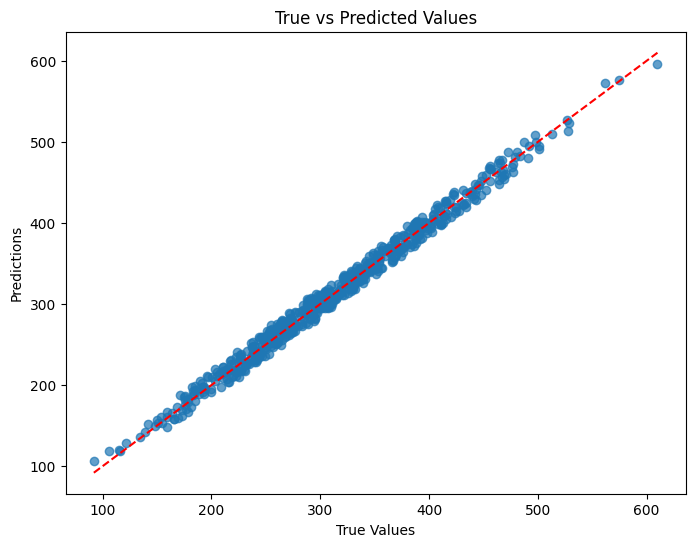

In [10]:
# visualize model performance 
plt.figure(figsize=(8, 6))
plt.scatter(true_values, predictions, alpha=0.7)
plt.plot([true_values.min(), true_values.max()], [true_values.min(), true_values.max()], 'r--')  # line for perfect predictions
plt.xlabel('True Values')
plt.ylabel('Predictions')
plt.title('True vs Predicted Values')
plt.show()

## ElasticNetCV with PCA for Days to Neutralization 

In [11]:
threat_name = "naval"
target_col = "actual_days_to_stabilization" # or "actual_days_to_stabilization"
df = load_and_clean_data(data_directory)
val_fraction = 0.2
random_state = 42
max_components = 26

# prepare data 
df = df.dropna() # drop rows with missing values for regression
input_columns = df.select_dtypes(include=[np.number]).columns.tolist()
# input_columns.remove('response_success')
input_columns.remove('Financial_Loss_MUSD')
input_columns.remove('actual_days_to_stabilization')

X = df[input_columns] # pd df of input variables 
if target_col == 'Financial_Loss_MUSD':
    y =  df['Financial_Loss_MUSD']
elif target_col == 'actual_days_to_stabilization':
    y = df['actual_days_to_stabilization']
else:
    raise ValueError(f"Invalid target_col: {target_col}. Must be 'Financial_Loss_MUSD' or 'actual_days_to_stabilization'.")
    
# train test (val) split 
val_size = int(len(X) * val_fraction)
indices = np.arange(len(X))
np.random.seed(random_state)
np.random.shuffle(indices)
    
val_indices = indices[:val_size]
train_indices = indices[val_size:]

X_train, X_val = X.iloc[train_indices], X.iloc[val_indices]
y_train, y_val = y.iloc[train_indices], y.iloc[val_indices]

# standardize 
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
    
# fit PCA with all components to get all eigenvalues
max_possible_components = min(max_components, X_train_scaled.shape[1], X_train_scaled.shape[0])
pca_full = PCA(n_components=max_possible_components)
pca_full.fit(X_train_scaled)

# test different numbers of components to find the best
best_mse = float('inf')
best_n_components = 1
best_model = None
best_pca = None

print(f"Testing {max_possible_components} different PCA configurations...")

for n_comp in range(1, max_possible_components + 1):
    # apply PCA with n_comp components
    pca = PCA(n_components=n_comp)
    X_train_pca = pca.fit_transform(X_train_scaled)
    X_val_pca = pca.transform(X_val_scaled)
    
    # train linear regression
    regr = ElasticNetCV(l1_ratio = [.1, .5, .7, .9, .95, .99, 1], cv=5, random_state=0)
    regr.fit(X_train_pca, y_train)
    
    # Evaluate on validation set
    val_mse = mean_squared_error(y_val, regr.predict(X_val_pca))
    
    if val_mse < best_mse:
        best_mse = val_mse
        best_n_components = n_comp
        best_model = regr
        best_pca = pca
        
# Report best configuration
print(f"\nBest Configuration:")
print(f"  Number of components: {best_n_components}")
print(f"  Validation MSE: {best_mse:.4f}")
cumulative_variance = np.sum(best_pca.explained_variance_ratio_) * 100
print(f"  Cumulative variance explained: {cumulative_variance:.2f}%")

Testing 25 different PCA configurations...

Best Configuration:
  Number of components: 25
  Validation MSE: 3.5733
  Cumulative variance explained: 100.00%


Mean Absolute Error (MAE): 1.469321
Root Mean Squared Error (RMSE): 1.890328
R² Score: 0.871578
Mean Absolute Percentage Error (MAPE): 26.33%


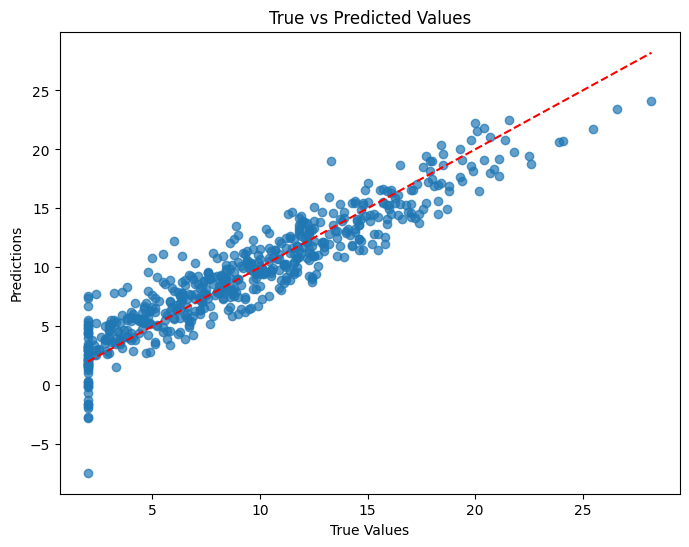

In [12]:
# get test metrics 
true_values = y_val
predictions = best_model.predict(best_pca.transform(X_val_scaled))
calculate_metrics(true_values, predictions)

# visualize model performance 
plt.figure(figsize=(8, 6))
plt.scatter(true_values, predictions, alpha=0.7)
plt.plot([true_values.min(), true_values.max()], [true_values.min(), true_values.max()], 'r--')  # line for perfect predictions
plt.xlabel('True Values')
plt.ylabel('Predictions')
plt.title('True vs Predicted Values')
plt.show()

In [13]:
df = load_and_clean_data(data_directory)

df['Threat Type'].unique()

<StringArray>
['missile', 'air', 'cyber', 'hybrid', 'naval']
Length: 5, dtype: str

In [14]:
df[df['Threat Type'] == 'air']

,Threat Type,enemy_unit_count,Enemy.Capability.Index,ThreatEscalationHours,friendlyUnitCount,LCS_COUNT,Aircraft Count,cyber_defense_teams,Patriot.Batteries,ISR_AssetCount,...,CMD_COORD_SCORE,roe_complexity_score,Operational Budget (MUSD),BudgetUtilization_pct,Weather_Severity,Theater Distance KM,Season,response_success,Financial_Loss_MUSD,actual_days_to_stabilization
2,air,7,3,48,45,0,5,0,0,14,...,9,1,92,88,0,6706.5,Winter,1,280,2.0
10,air,9,2,19,19,0,24,0,0,1,...,10,3,79,73,4,607.8,Spring,1,309,9.1
13,air,5,9,10,27,0,12,0,0,6,...,7,4,274,68,1,5076.0,Spring,0,432,12.6
14,air,44,1,63,9,0,12,0,0,3,...,6,1,116,88,8,1418.9,Fall,1,290,11.4
18,air,47,6,47,31,0,18,0,0,4,...,5,5,475,95,0,5392.2,Fall,1,423,9.9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2968,air,3,10,26,48,0,6,0,0,11,...,4,1,257,84,6,6328.3,Spring,1,313,9.4
2969,air,6,4,50,58,0,24,0,0,4,...,7,4,460,86,0,8338.9,Winter,1,424,9.0
2981,air,49,5,7,6,0,18,0,0,12,...,8,5,335,97,8,4261.8,Spring,1,492,10.5
2987,air,29,10,3,40,0,16,0,0,2,...,1,3,396,69,3,1574.7,Winter,1,307,13.3


In [ ]:
# get metrics for each threat type and target variable 
# prepare data 
df = df.dropna() # drop rows with missing values for regression
input_columns = df.select_dtypes(include=[np.number]).columns.tolist()
# input_columns.remove('response_success')
input_columns.remove('Financial_Loss_MUSD')
input_columns.remove('actual_days_to_stabilization')
val_fraction = 0.2
random_state = 42
max_components = 26

threats =  df['Threat Type'].unique()
targets = ['Financial_Loss_MUSD', 'actual_days_to_stabilization']

# create empty df to store metrics for each threat type and target variable
metrics_df = pd.DataFrame(columns=['Threat Type', 'target_col', 'MAE', 'RMSE', 'R2', 'MAPE'])

for threat_name in threats:
    for target_col in targets:
        # print(f"Calculating metrics for threat type: {threat_name}, target: {target_col}")

        threat_df = df[df['Threat Type'] == threat_name] # filter to this threat type

        X = threat_df[input_columns] # pd df of input variables 
        if target_col == 'Financial_Loss_MUSD':
            y =  threat_df['Financial_Loss_MUSD']
        elif target_col == 'actual_days_to_stabilization':
            y = threat_df['actual_days_to_stabilization']
         
        # train test (val) split 
        val_size = int(len(X) * val_fraction)
        indices = np.arange(len(X))
        np.random.seed(random_state)
        np.random.shuffle(indices)
            
        val_indices = indices[:val_size]
        train_indices = indices[val_size:]

        X_train, X_val = X.iloc[train_indices], X.iloc[val_indices]
        y_train, y_val = y.iloc[train_indices], y.iloc[val_indices]

        # standardize 
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_val_scaled = scaler.transform(X_val)
            
        # fit PCA with all components to get all eigenvalues
        max_possible_components = min(max_components, X_train_scaled.shape[1], X_train_scaled.shape[0])
        pca_full = PCA(n_components=max_possible_components)
        pca_full.fit(X_train_scaled)

        # test different numbers of components to find the best
        best_mse = float('inf')
        best_n_components = 1
        best_model = None
        best_pca = None

        # print(f"Testing {max_possible_components} different PCA configurations...")

        for n_comp in range(1, max_possible_components + 1):
            # apply PCA with n_comp components
            pca = PCA(n_components=n_comp)
            X_train_pca = pca.fit_transform(X_train_scaled)
            X_val_pca = pca.transform(X_val_scaled)
            
            # train linear regression
            regr = ElasticNetCV(l1_ratio = [.1, .5, .7, .9, .95, .99, 1], cv=5, random_state=0)
            regr.fit(X_train_pca, y_train)
            
            # Evaluate on validation set
            val_mse = mean_squared_error(y_val, regr.predict(X_val_pca))
            
            if val_mse < best_mse:
                best_mse = val_mse
                best_n_components = n_comp
                best_model = regr
                best_pca = pca
                
        # get test metrics 
        true_values = y_val
        predictions = best_model.predict(best_pca.transform(X_val_scaled))

        # populate df with metrics for this threat type and target variable
        mae, r2, rmse, mape = calculate_metrics(true_values, predictions, print_results = False)

        metrics_df.loc[len(metrics_df)] = {
            'Threat Type': threat_name,
            'target_col': target_col,
            'MAE': mae,
            'RMSE': rmse,
            'R2': r2,
            'MAPE': mape
        }

# add average metrics across all threat types for each target variable
average_metrics = metrics_df.groupby('target_col').agg({
    'MAE': 'mean',
    'RMSE': 'mean',
    'R2': 'mean',
    'MAPE': 'mean'
}).reset_index()

# append average metrics to the main metrics_df
metrics_df = pd.concat([metrics_df, average_metrics], ignore_index=True)


metrics_df

Metrics for threat type: missile, target: Financial_Loss_MUSD
Metrics for threat type: missile, target: actual_days_to_stabilization
Metrics for threat type: air, target: Financial_Loss_MUSD
Metrics for threat type: air, target: actual_days_to_stabilization
Metrics for threat type: cyber, target: Financial_Loss_MUSD
Metrics for threat type: cyber, target: actual_days_to_stabilization
Metrics for threat type: hybrid, target: Financial_Loss_MUSD
Metrics for threat type: hybrid, target: actual_days_to_stabilization
Metrics for threat type: naval, target: Financial_Loss_MUSD
Metrics for threat type: naval, target: actual_days_to_stabilization


,Threat Type,target_col,MAE,RMSE,R2,MAPE
0,missile,Financial_Loss_MUSD,7.655523,8.937078,0.987365,2.608285
1,missile,actual_days_to_stabilization,0.822476,1.023490,0.949672,14.522337
2,air,Financial_Loss_MUSD,7.777638,9.121783,0.986188,2.313594
3,air,actual_days_to_stabilization,0.836669,0.996023,0.954224,15.176135
4,cyber,Financial_Loss_MUSD,8.012346,9.164842,0.985168,3.136878
5,cyber,actual_days_to_stabilization,0.927025,1.190495,0.895933,26.135829
6,hybrid,Financial_Loss_MUSD,7.352032,8.619032,0.989067,2.857270
7,hybrid,actual_days_to_stabilization,0.656937,0.795629,0.973319,5.872730
8,naval,Financial_Loss_MUSD,7.893182,9.069811,0.987105,2.642758
9,naval,actual_days_to_stabilization,0.875983,1.054063,0.952952,14.973723
